In [1]:
import sys
import os
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

import seaborn as sns
sns.set_style('darkgrid')

from src.Market_v2 import Market

In [2]:
from joblib import dump, load

market = load(project_root / "results/market_simulation_normal_garch_norm.joblib")

In [3]:
np.random.seed(42)

In [6]:
df = market.summary()
df.index.name = 'Asset number'

df = df.reset_index()[['Asset number', 'alpha', 'beta', "sector_coeffs", 'vol_premium', "sector"]]

In [47]:
latex_table = df.to_latex(
    index=False,  # To not include the DataFrame index as a column in the table
    caption="Example generated market",  # The caption to appear above the table in the LaTeX document
    label="tab:market_summary",  # A label used for referencing the table within the LaTeX document
    position="htbp",  # The preferred positions where the table should be placed in the document ('here', 'top', 'bottom', 'page')
    column_format="lccccc",  # The format of the columns: left-aligend first column and center-aligned remaining columns as per APA guidelines
    escape=True,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.4f}".format  # Formats floats to two decimal places
)

print(latex_table)

\begin{table}[htbp]
\caption{Example generated market}
\label{tab:market_summary}
\begin{tabular}{lccccc}
\toprule
Asset number & alpha & beta & sector\_coeffs & vol\_premium & sector \\
\midrule
0 & 0.0003 & 2.9811 & 1.6648 & -4.7903 & 2 \\
1 & 0.0000 & 2.6426 & 1.5212 & 4.1084 & 2 \\
2 & -0.0002 & 3.0926 & 2.0432 & 4.1156 & 1 \\
3 & 0.0001 & 3.2506 & 1.7883 & 4.6629 & 1 \\
4 & 0.0002 & 3.9287 & 1.9899 & -5.4153 & 0 \\
5 & 0.0000 & 2.9495 & 1.6155 & -4.3655 & 2 \\
6 & 0.0001 & 2.9501 & 1.8710 & -3.7246 & 0 \\
7 & -0.0001 & 2.8914 & 1.6633 & -3.7760 & 0 \\
8 & 0.0002 & 2.5682 & 1.5643 & -4.0604 & 1 \\
9 & 0.0000 & 1.9948 & 1.4153 & 2.8482 & 1 \\
\bottomrule
\end{tabular}
\end{table}



In [8]:
n_simulations = 100
nobs = 252

sims = np.zeros((n_simulations, nobs, market.n_assets))
vols = np.zeros((n_simulations, nobs))
sects = np.zeros((n_simulations, nobs, market.n_sectors))
market_returns = np.zeros((n_simulations, nobs))

for i in range(100):
    sim, m, vol, sect = market.simulate(nobs, burn=500, return_sectors=True)
    sims[i] = sim
    market_returns[i] = m
    vols[i] = vol
    sects[i] = sect

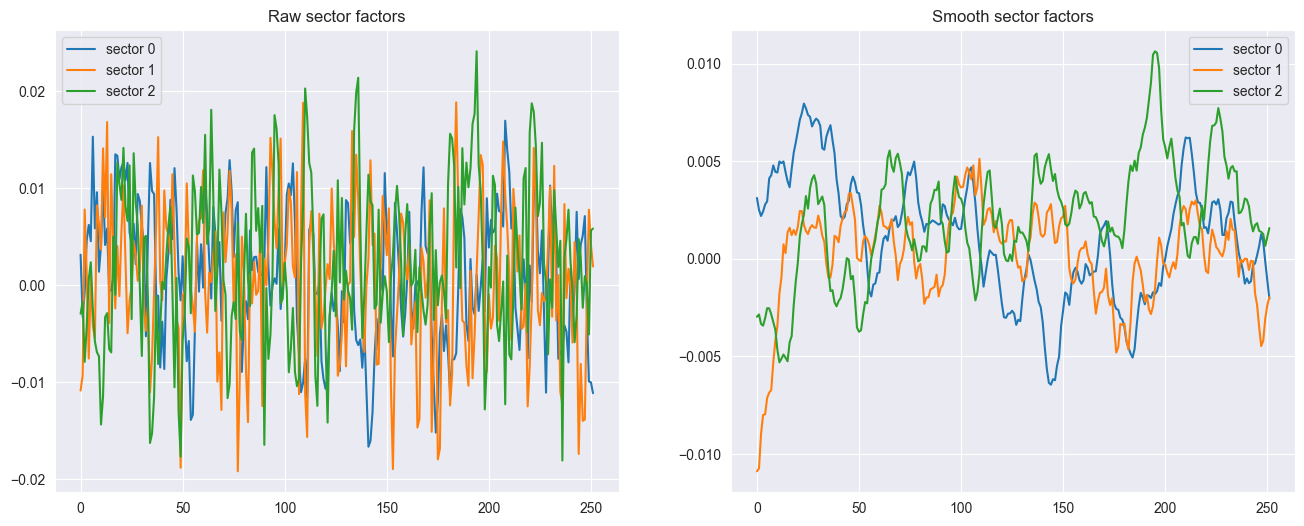

In [9]:
import matplotlib.pyplot as plt
from src.optimized_functions import ewma_2d, ewma_1d

fig, ax = plt.subplots(1,2, figsize=(16,6))

ax[0].plot(sects[0], label=[f"sector {j}" for j in range(market.n_sectors)])
ax[0].set_title("Raw sector factors")

ax[1].plot(ewma_2d(sects[0], 20) , label=[f"sector {j}" for j in range(market.n_sectors)])
ax[1].set_title("Smooth sector factors")

ax[0].legend()
ax[1].legend()

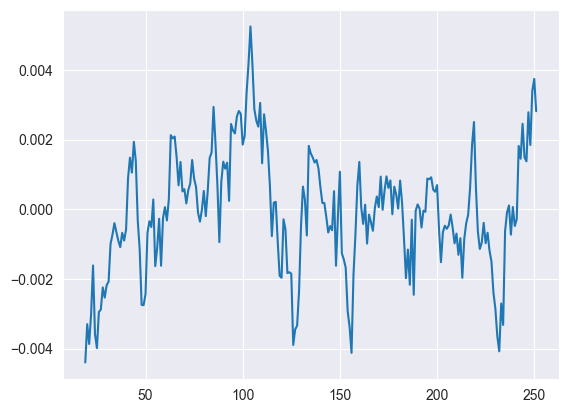

In [10]:
plt.plot(ewma_1d(market_returns[0], 20))

In [11]:
cont_sims = np.zeros((n_simulations, 20, market.n_assets))
cont_vols = np.zeros((n_simulations, 20))
cont_sects = np.zeros((n_simulations, 20, market.n_sectors))
cont_market_returns = np.zeros((n_simulations, 20))

for i in range(100):
    sim, m, vol, sect = market.simulate(20, burn = 0, initial_market_returns=market_returns[0, :20],
                                        initial_market_vols=vols[0, :20], 
                                        initial_sector_returns=sects[0, :20, :], 
                                        return_sectors=True)
    cont_sims[i] = sim
    cont_market_returns[i] = m
    cont_vols[i] = vol
    cont_sects[i] = sect

In [12]:
actual_sim, actual_m, actual_vol, actual_sect = market.simulate(20, burn = 0, initial_market_returns=market_returns[0, :20],
                                        initial_market_vols=vols[0, :20], 
                                        initial_sector_returns=sects[0, :20, :], 
                                        return_sectors=True)

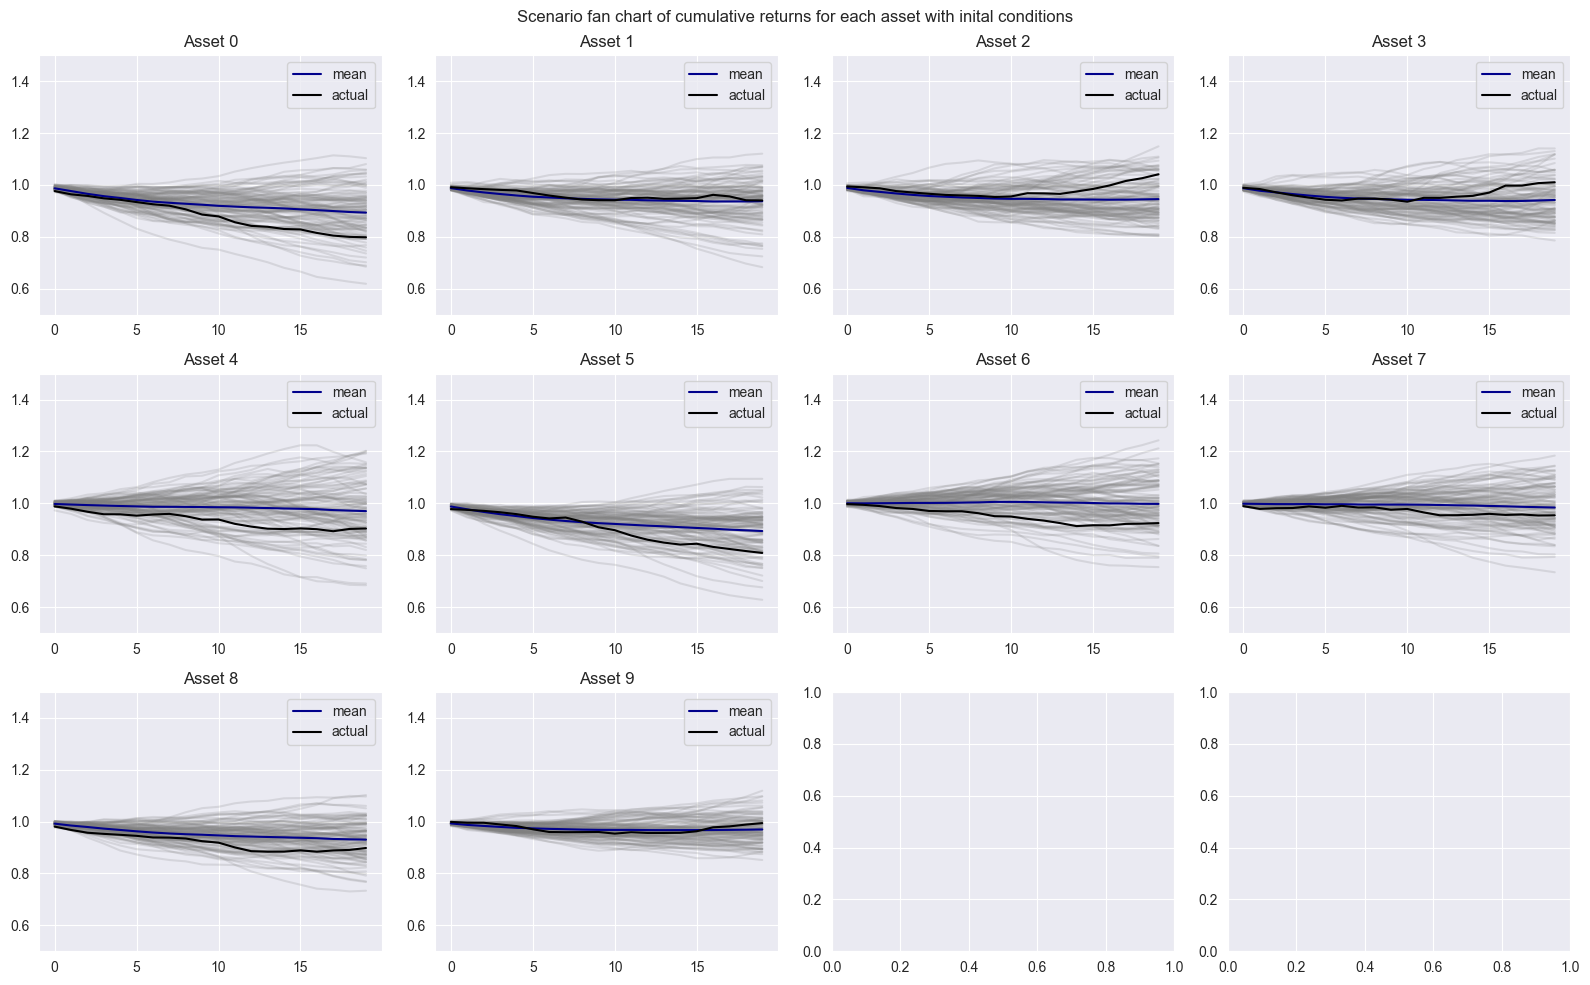

In [13]:
fig, ax = plt.subplots(3,4, figsize=(16,10))

fig.suptitle("Scenario fan chart of cumulative returns for each asset with inital conditions")

for i in range(market.n_assets):
    arr = np.array([np.exp(cont_sims[sim, :, i]).cumprod() for sim in range(n_simulations)])

    ax[i//4, i%4].plot(arr.T, alpha=0.2, color="gray")
    ax[i//4, i%4].plot(arr.mean(axis=0), label="mean", color='darkblue')
    ax[i//4, i%4].plot(np.exp(actual_sim[:, i]).cumprod(), label='actual', color='black')

    ax[i//4, i%4].set_ylim((0.5, 1.5))
    
    ax[i//4, i%4].set_title(f"Asset {i}")
    ax[i//4, i%4].legend()

    plt.tight_layout()

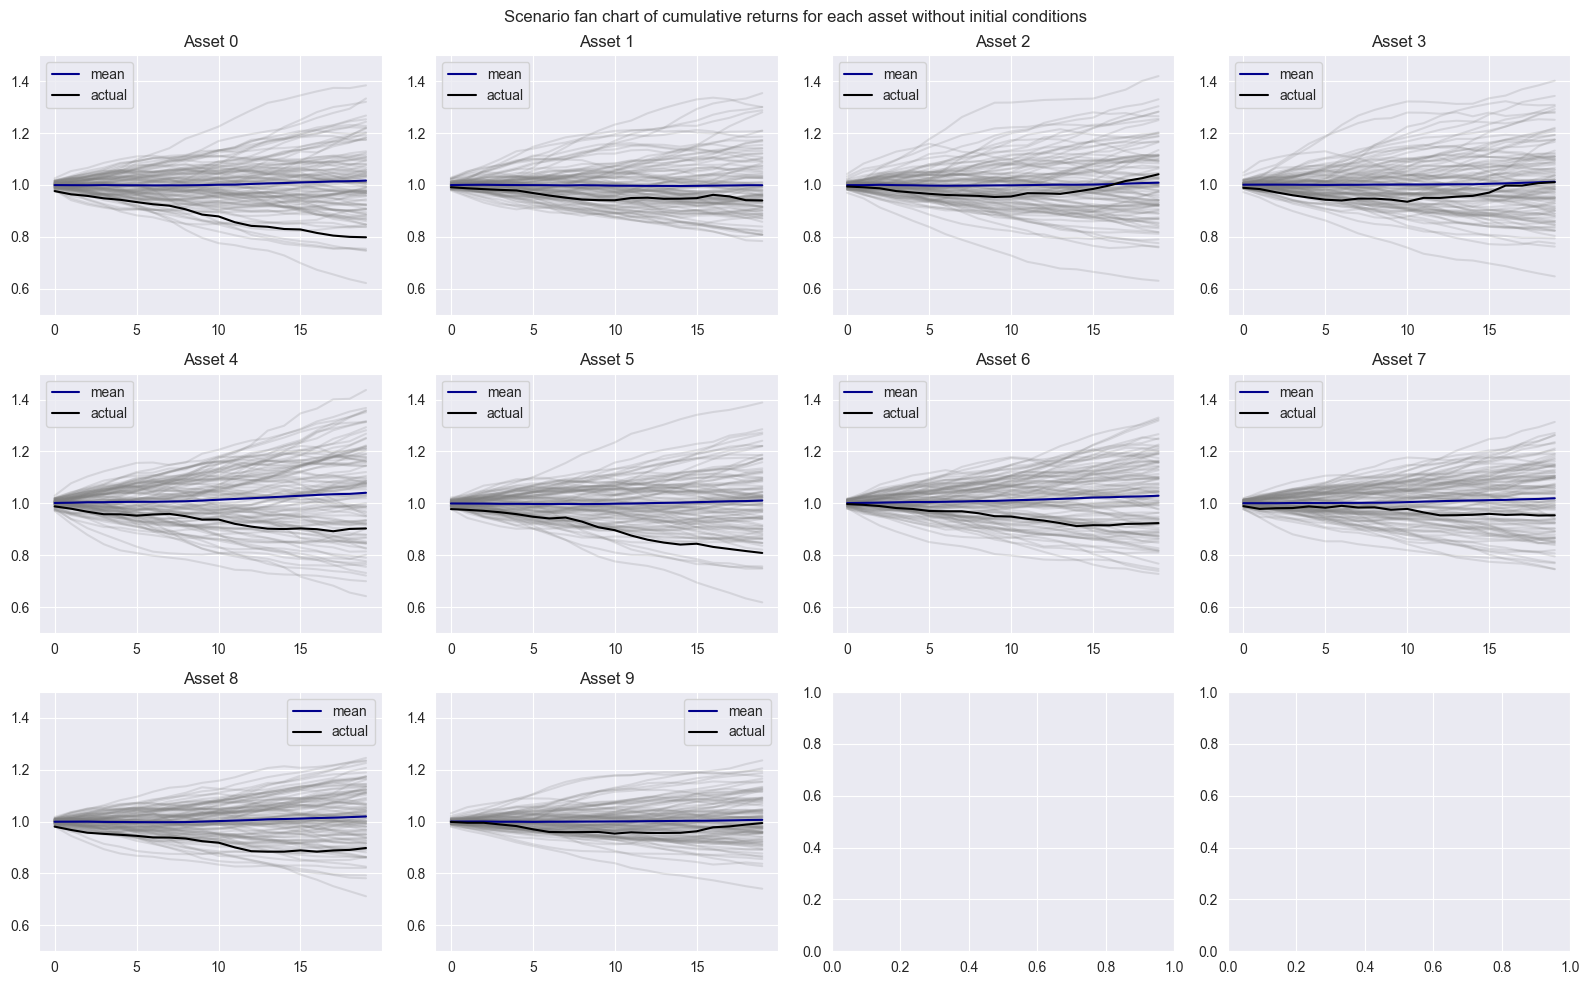

In [14]:
fig, ax = plt.subplots(3,4, figsize=(16,10))

fig.suptitle("Scenario fan chart of cumulative returns for each asset without initial conditions")

for i in range(market.n_assets):
    arr = np.array([np.exp(sims[sim, 20:40, i]).cumprod() for sim in range(n_simulations)])

    ax[i//4, i%4].plot(arr.T, alpha=0.2, color="gray")
    ax[i//4, i%4].plot(arr.mean(axis=0), label="mean", color='darkblue')
    ax[i//4, i%4].plot(np.exp(actual_sim[:, i]).cumprod(), label='actual', color='black')
    
    ax[i//4, i%4].set_ylim((0.5, 1.5))

    ax[i//4, i%4].set_title(f"Asset {i}")
    ax[i//4, i%4].legend()

    plt.tight_layout()

In [15]:
def grouped_boxplot_from_2dfs(cont_df, df_0, ax=None):

    # Add source labels
    cont_df['source'] = 'with_inital'
    df_0['source'] = 'no_initial'

    # Combine
    df = pd.concat([cont_df, df_0], ignore_index=True)

    # Convert to long format
    df_long = df.melt(
        id_vars='source',
        var_name='time',
        value_name='difference from actual return'
    )

    if ax is None:
        # Plot
        plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df_long,
        x='time',
        y='difference from actual return',
        hue='source',
        ax=ax
    )
    
    if ax is None:
        plt.title('Next step Grouped Boxplots of scenario returns')
        plt.show()

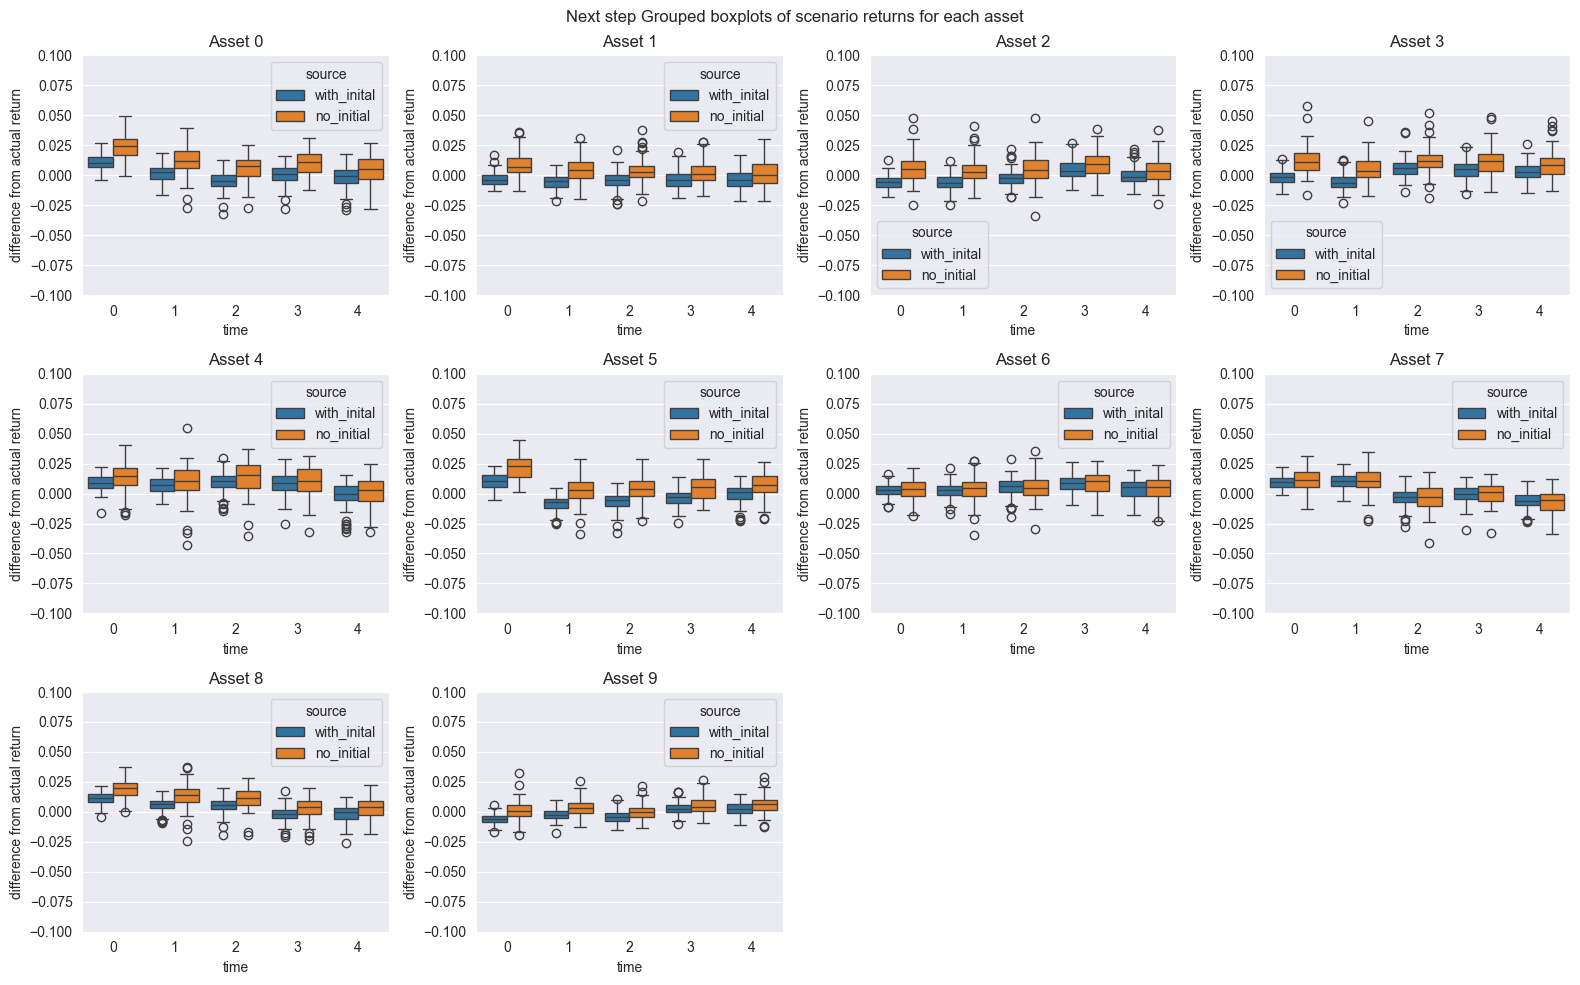

In [42]:
fig, ax = plt.subplots(3,4, figsize=(16,10))

fig.suptitle("Next step Grouped boxplots of scenario returns for each asset")

for i in range(12):
    if i >= market.n_assets:
        ax[i//4, i%4].axis('off')  # hide axes for non-existent assets
        continue
    
    cont_df = pd.DataFrame([cont_sims[:, t, i]  - actual_sim[t, i] for t in range(5)])
    df_0 = pd.DataFrame([sims[:, t+20, i] - actual_sim[t, i] for t in range(5)])
    cont_df, df_0 = cont_df.T, df_0.T

    grouped_boxplot_from_2dfs(cont_df, df_0, ax=ax[i//4, i%4])
    ax[i//4, i%4].set_title(f"Asset {i}")
    ax[i//4, i%4].set_ylim((-0.1, 0.1))

    plt.tight_layout()

Text(0.5, 1.0, 'Correlation matrix of simulation 0')

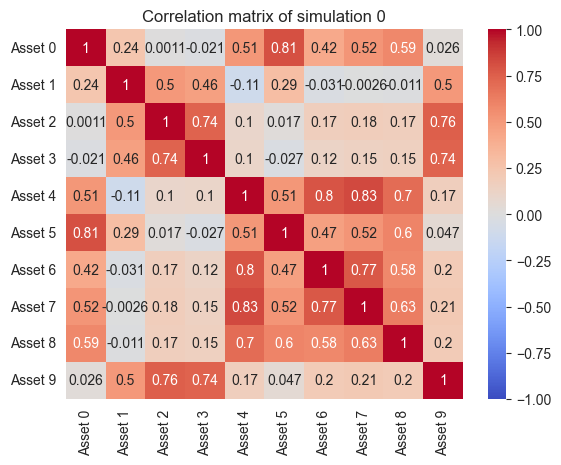

In [18]:
heat_map=sns.heatmap(np.corrcoef(sims[0].T), annot=True, cmap='coolwarm',vmin=-1, vmax=1,
             xticklabels=[f"Asset {i}" for i in range(market.n_assets)], yticklabels=[f"Asset {i}" for i in range(market.n_assets)])
heat_map.set_title(f"Correlation matrix of simulation {0}")

In [19]:
vols.shape

(100, 252)

In [20]:
vols[i].shape

(252,)

In [21]:
from src.optimized_functions import ewma_1d
corrs = np.zeros(100, dtype=float)
for i in range(100):
    smooth_vol = ewma_1d(vols[i], 20)
    vol_premia = vols[i, 21:] - smooth_vol[21:]

    smooth_market = ewma_1d(market_returns[i], 20)[21:]

    corrs[i] = np.corrcoef(market_returns[i], vols[i])[0,1]
corrs = pd.Series(corrs)

In [46]:
corrs.mean(), corrs.std(), corrs.sem()

(np.float64(0.0013705815466710752),
 np.float64(0.07247951366338065),
 np.float64(0.007247951366338065))

In [23]:
import numpy as np
from scipy import stats

# your 100 correlations
r = np.array(corrs)

# avoid exactly +/-1
eps = 1e-12
r = np.clip(r, -1 + eps, 1 - eps)

# Fisher z transform
z = np.arctanh(r)

# one-sample t-test against 0
t_stat, p_value = stats.ttest_1samp(z, popmean=0)

print(t_stat, p_value)

0.18747450577054725 0.8516723070646499


In [44]:
t_stat, p_value = stats.ttest_1samp(corrs, popmean=0)

print(t_stat, p_value)

0.18909916435649926 0.850402227926079


(array([ 1.,  4.,  5., 10., 21., 19., 15., 14.,  6.,  5.]),
 array([-0.19819853, -0.16217737, -0.12615622, -0.09013507, -0.05411392,
        -0.01809277,  0.01792839,  0.05394954,  0.08997069,  0.12599184,
         0.16201299]),
 <BarContainer object of 10 artists>)

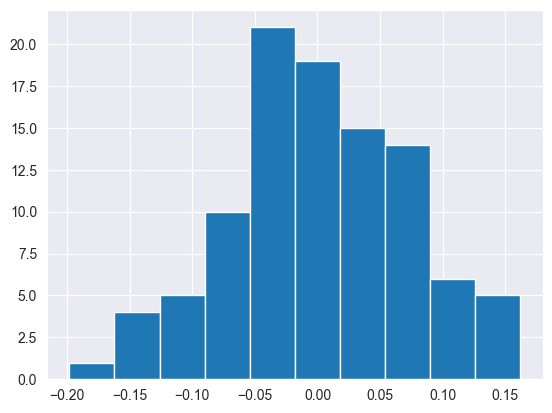

In [26]:
plt.hist(corrs, bins=10)

(-0.005, 0.005)

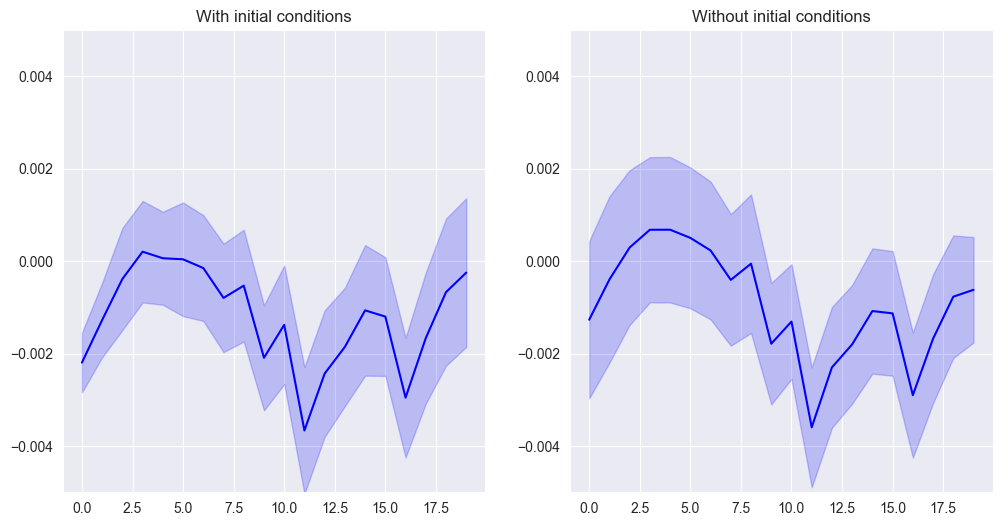

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

ax[0].plot((cont_vols.T - actual_vol[:, None]).mean(axis=1), color="blue")
ax[1].plot((vols[:, 20:40].T - actual_vol[:, None]).mean(axis=1), color="blue")

ax[0].fill_between(range(20), (cont_vols.T - actual_vol[:, None]).mean(axis=1) - (cont_vols.T - actual_vol[:, None]).std(axis=1),
                    (cont_vols.T - actual_vol[:, None]).mean(axis=1) + (cont_vols.T - actual_vol[:, None]).std(axis=1), alpha=0.2, color="blue")

ax[1].fill_between(range(20), (vols[:, 20:40].T - actual_vol[:, None]).mean(axis=1) - (vols[:, 20:40].T - actual_vol[:, None]).std(axis=1),
                    (vols[:, 20:40].T - actual_vol[:, None]).mean(axis=1) + (vols[:, 20:40].T - actual_vol[:, None]).std(axis=1), alpha=0.2, color="blue")

ax[0].set_title("With initial conditions")
ax[1].set_title("Without initial conditions")

ax[0].set_ylim((-0.005, 0.005))
ax[1].set_ylim((-0.005, 0.005))

#plt.plot(actual_vol, color="black")

# Trajectories

In [28]:
market_returns_df = pd.DataFrame(market_returns)

<Axes: title={'center': 'Mean cumulative asset retuns (No inital conditions)'}>

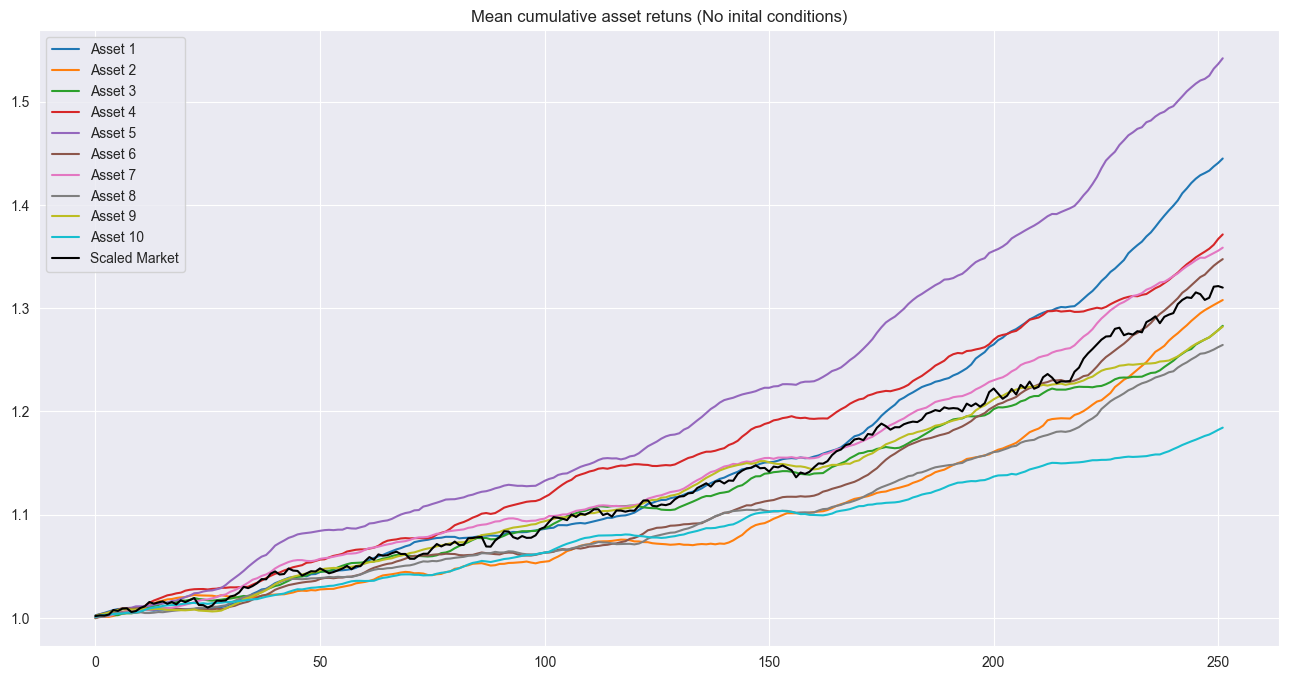

In [29]:
for i in range(market.n_assets):
    asset_returns = pd.DataFrame(sims[:, :, i])

    np.exp(asset_returns).cumprod(axis=1).mean().plot(legend=True, label=f'Asset {i+1}', figsize=(16,8))
np.exp(market_returns_df * market.betas.mean()).cumprod(axis=1).mean().plot(legend=True, label=f'Scaled Market', 
                                                                            figsize=(16,8), color='black', title='Mean cumulative asset retuns (No inital conditions)')

<Axes: title={'center': 'Simulation 7'}>

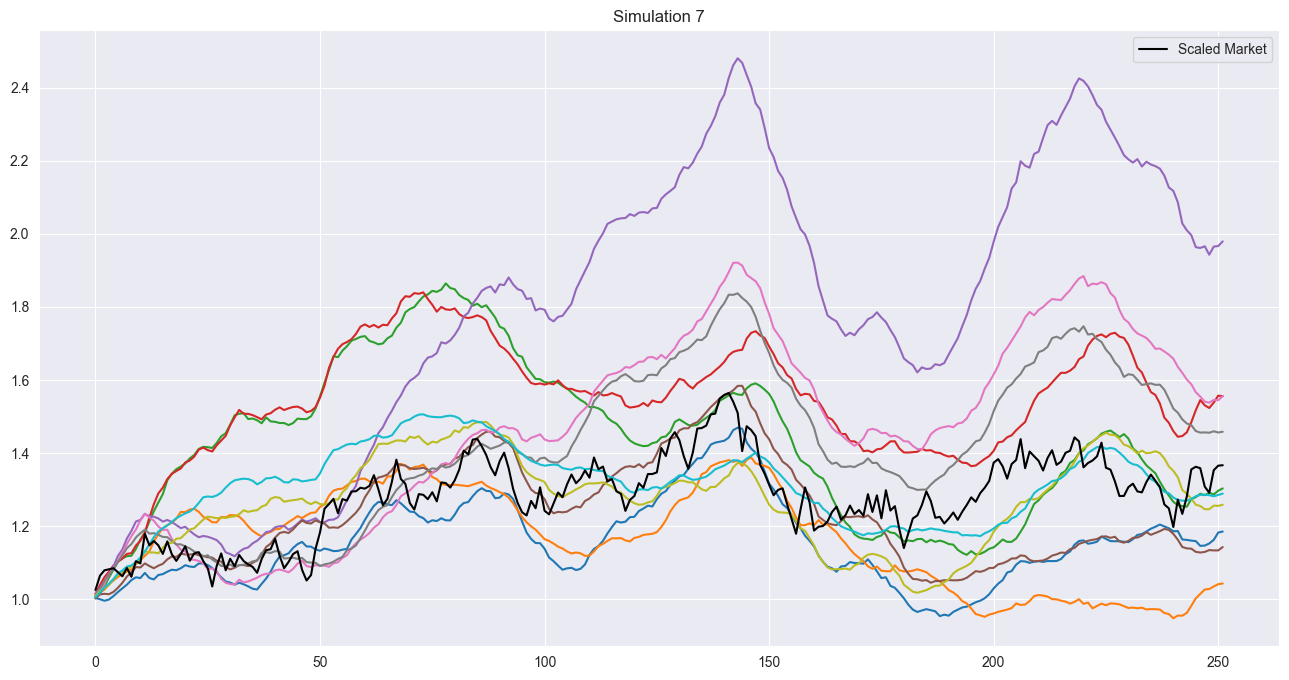

In [33]:
fig, ax = plt.subplots(1,1)

sim_num = 7

for i in range(market.n_assets):
    asset_returns = pd.DataFrame(sims[sim_num, :, i])

    np.exp(asset_returns).cumprod().plot(legend=False, label=f'Asset {i+1}', figsize=(16,8), ax=ax)

np.exp(market_returns_df.loc[sim_num] * market.betas.mean()).cumprod().plot(legend=True, label=f'Scaled Market', figsize=(16,8), color='black', ax=ax, title=f'Simulation {sim_num}')

In [34]:
long_cont_sims = np.zeros((n_simulations, 252, market.n_assets))
long_cont_vols = np.zeros((n_simulations, 252))
long_cont_sects = np.zeros((n_simulations, 252, market.n_sectors))
long_cont_market_returns = np.zeros((n_simulations, 252))

for i in range(100):
    sim, m, vol, sect = market.simulate(252, burn = 0, initial_market_returns=market_returns[0, :20],
                                        initial_market_vols=vols[0, :20], 
                                        initial_sector_returns=sects[0, :20, :], 
                                        return_sectors=True)
    long_cont_sims[i] = sim
    long_cont_market_returns[i] = m
    long_cont_vols[i] = vol
    long_cont_sects[i] = sect

In [35]:
cont_market_returns_df = pd.DataFrame(cont_market_returns)

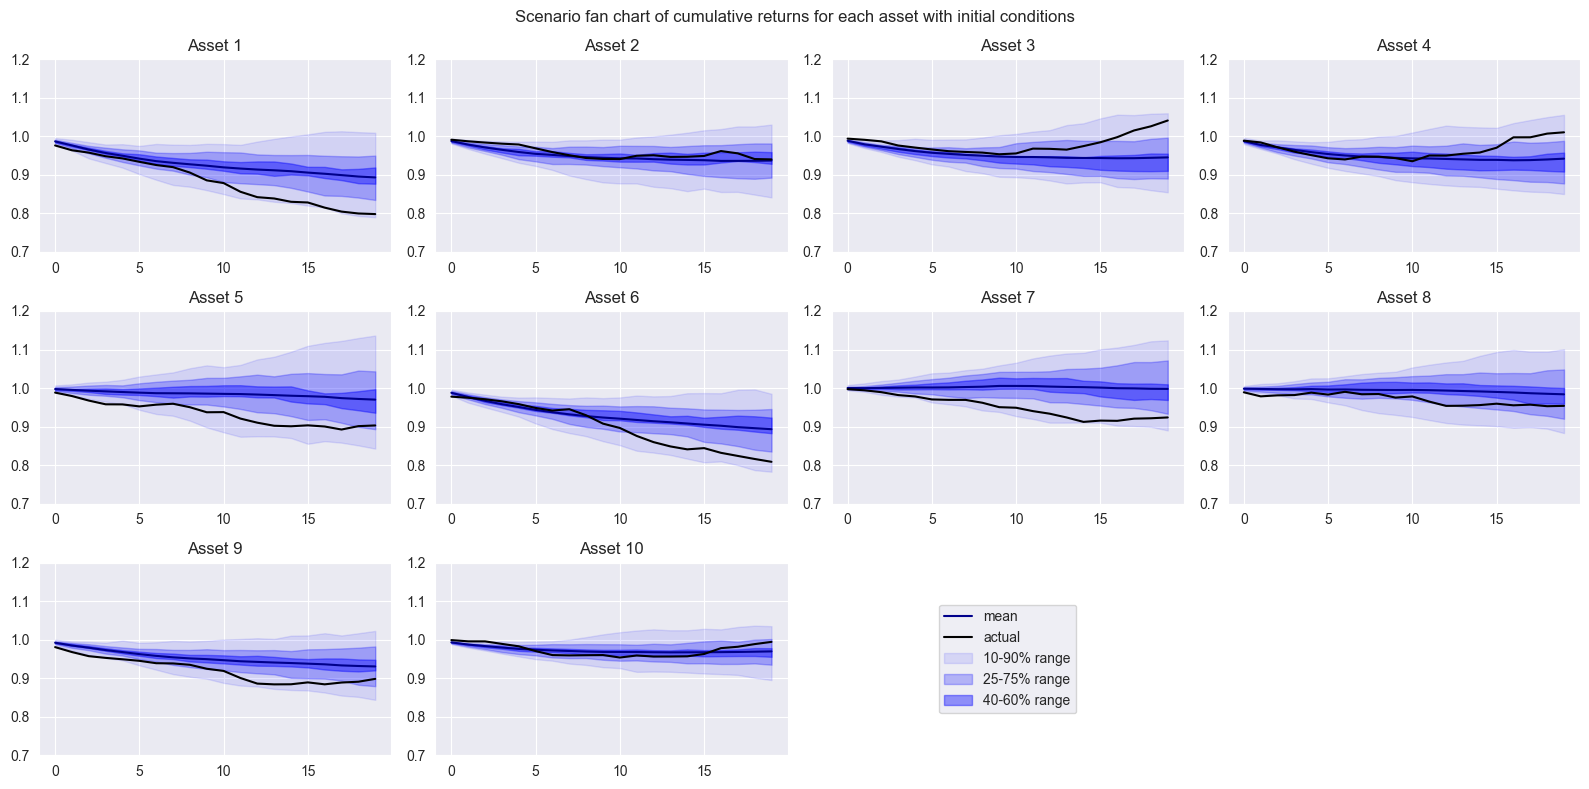

In [40]:
fig, ax = plt.subplots(3,4, figsize=(16,10))
fig.suptitle("Scenario fan chart of cumulative returns for each asset with initial conditions")

for i in range(market.n_assets):
    asset_returns = pd.DataFrame(cont_sims[:, :, i])

    traj = np.exp(asset_returns).cumprod(axis=1)

    traj.mean().plot(legend=False, title=f'Asset {i+1}', figsize=(16,8), ax=ax[i//4, i%4], color='darkblue', label='mean')
    ax[i//4, i%4].plot(np.exp(actual_sim[:, i]).cumprod(), color='black', label="actual")

    for q in [0.1, 0.25, 0.4]:
        ax[i//4, i%4].fill_between(range(20), traj.quantile(q, axis=0), traj.quantile(1-q, axis=0), alpha=q, label=f"{int(q*100)}-{int((1-q)*100)}% range", color="blue")

    #ax[i//4, i%4].fill_between(range(20), traj.mean() - traj.std(), traj.mean() + traj.std(), alpha=0.2, label="std range")
    #ax[i//4, i%4].legend()
    ax[i//4, i%4].set_ylim((0.7, 1.2))

# set the legend to next axis
ax[market.n_assets//4, market.n_assets%4].axis('off')  # hide axes
ax[(market.n_assets+1)//4, (market.n_assets+1)%4].axis('off')

handles, labels = ax[0, 0].get_legend_handles_labels()

ax[market.n_assets//4, market.n_assets%4].legend(handles, labels, loc='center')
plt.tight_layout()

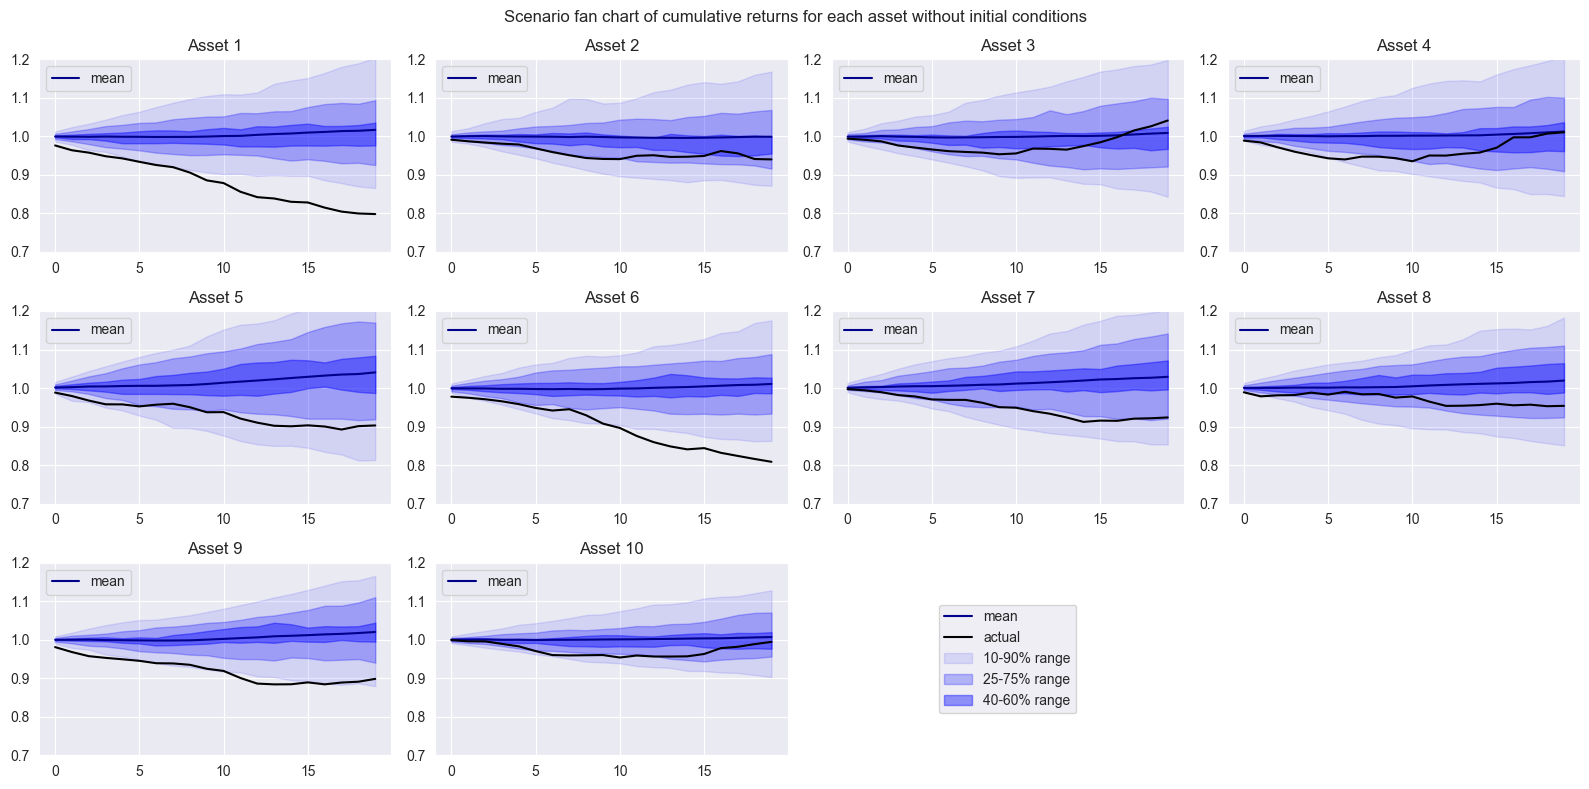

In [41]:
fig, ax = plt.subplots(3,4, figsize=(16,10))
fig.suptitle("Scenario fan chart of cumulative returns for each asset without initial conditions")

for i in range(market.n_assets):
    asset_returns = pd.DataFrame(sims[:, 20:40, i])

    traj = np.exp(asset_returns).cumprod(axis=1)

    np.exp(asset_returns).cumprod(axis=1).mean().plot(legend=True, title=f'Asset {i+1}', figsize=(16,8), ax=ax[i//4, i%4], color='darkblue', label='mean')
    ax[i//4, i%4].plot(np.exp(actual_sim[:, i]).cumprod(), color='black', label="actual")

    for q in [0.1, 0.25, 0.4]:
        ax[i//4, i%4].fill_between(range(20), traj.quantile(q, axis=0), traj.quantile(1-q, axis=0), alpha=q, label=f"{int(q*100)}-{int((1-q)*100)}% range", color="blue")

    #ax[i//4, i%4].fill_between(range(20), traj.mean() - traj.std(), traj.mean() + traj.std(), alpha=0.1, label="std range", color="blue")
    #ax[i//4, i%4].legend()
    ax[i//4, i%4].set_ylim((0.7, 1.2))

# set the legend to next axis
ax[market.n_assets//4, market.n_assets%4].axis('off')  # hide axes
ax[(market.n_assets+1)//4, (market.n_assets+1)%4].axis('off')

handles, labels = ax[0, 0].get_legend_handles_labels()

ax[market.n_assets//4, market.n_assets%4].legend(handles, labels, loc='center')
plt.tight_layout()